In [1]:
!pip install gradio

In [2]:
# import Libraries

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Ensure plots are displayed inline (default in Colab but good practice)
%matplotlib inline

# Set default aesthetic parameters for seaborn
sns.set_theme(style="whitegrid")

print("Visualization and dimensionality reduction libraries imported successfully.")

print("Libraries imported successfully.")

Visualization and dimensionality reduction libraries imported successfully.
Libraries imported successfully.


## Data Loading and Preprocessing

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please ensure the file is uploaded to the environment.")

if 'df' in locals():
    # Check for missing values
    missing_counts = df.isnull().sum().sum()
    if missing_counts > 0:
        print(f"Found {missing_counts} missing values. Dropping rows with missing data.")
        df = df.dropna()
    else:
        print("No missing values found.")

    # Separate features and target
    X = df.drop(columns=['Class'])
    y = df['Class']

    # Initialize and apply StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"Features scaled. Shape of X_scaled: {X_scaled.shape}")
    print(df.head())

Dataset loaded successfully.
No missing values found.
Features scaled. Shape of X_scaled: (284807, 30)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.27053

**Reasoning**:
Since the dataset 'creditcard.csv' is missing from the environment, I will use a reliable external URL to download the dataset so the subtask can proceed.



In [4]:
import os
import urllib.request

# URL for the creditcard.csv dataset (Open Source mirror)
dataset_url = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'
file_path = 'creditcard.csv'

if not os.path.exists(file_path):
    print('Downloading creditcard.csv...')
    urllib.request.urlretrieve(dataset_url, file_path)
    print('Download complete.')
else:
    print('File already exists.')

# Confirm file existence and size
if os.path.exists(file_path):
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f'File confirmed: {file_path} ({size:.2f} MB)')

File already exists.
File confirmed: creditcard.csv (143.84 MB)


## pandas DataFrame

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset from the local file
df = pd.read_csv('creditcard.csv')
print("Dataset loaded successfully.")

# Check for missing values
missing_counts = df.isnull().sum().sum()
if missing_counts > 0:
    print(f"Found {missing_counts} missing values. Dropping rows.")
    df = df.dropna()
else:
    print("No missing values found.")

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data preprocessing complete.")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Dataset loaded successfully.
No missing values found.
Data preprocessing complete.
X_scaled shape: (284807, 30)
Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [24]:
print("Missing values before handling:")
print(df.isnull().sum())

df.dropna(inplace=True)
print("\nMissing values after handling:")
print(df.isnull().sum())

features = df.drop(['Time', 'Class'], axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
display(scaled_df.head())

Missing values before handling:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Missing values after handling:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.694242,-0.044075,1.672773,0.973366,-0.245117,0.347068,0.193679,0.082637,0.331128,0.083386,...,0.326118,-0.024923,0.382854,-0.176911,0.110507,0.246585,-0.392170,0.330892,-0.063781,0.244964
1,0.608496,0.161176,0.109797,0.316523,0.043483,-0.061820,-0.063700,0.071253,-0.232494,-0.153350,...,-0.089611,-0.307377,-0.880077,0.162201,-0.561131,0.320694,0.261069,-0.022256,0.044608,-0.342475
2,-0.693500,-0.811578,1.169468,0.268231,-0.364572,1.351454,0.639776,0.207373,-1.378675,0.190700,...,0.680975,0.337632,1.063358,1.456320,-1.138092,-0.628537,-0.288447,-0.137137,-0.181021,1.160686
3,-0.493325,-0.112169,1.182516,-0.609727,-0.007469,0.936150,0.192071,0.316018,-1.262503,-0.050468,...,-0.269855,-0.147443,0.007267,-0.304777,-1.941027,1.241904,-0.460217,0.155396,0.186189,0.140534
4,-0.591330,0.531541,1.021412,0.284655,-0.295015,0.071999,0.479302,-0.226510,0.744326,0.691625,...,0.529939,-0.012839,1.100011,-0.220123,0.233250,-0.395202,1.041611,0.543620,0.651816,-0.073403


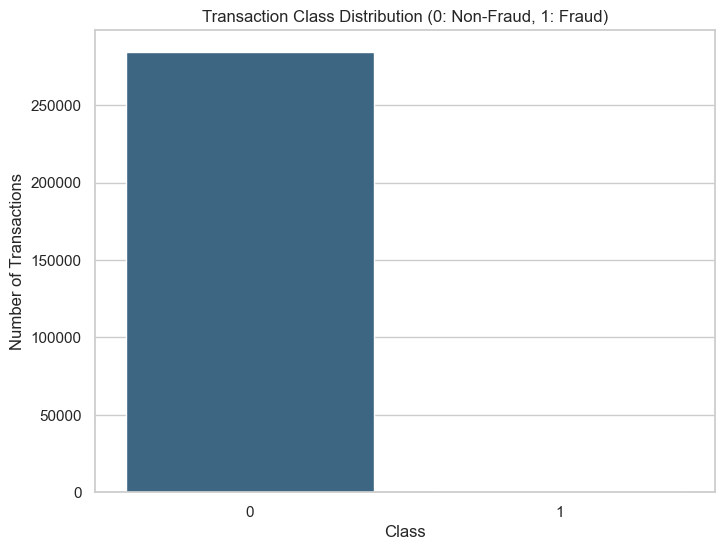

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the count plot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)

# Add titles and labels
plt.title('Transaction Class Distribution (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

# Display the plot
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

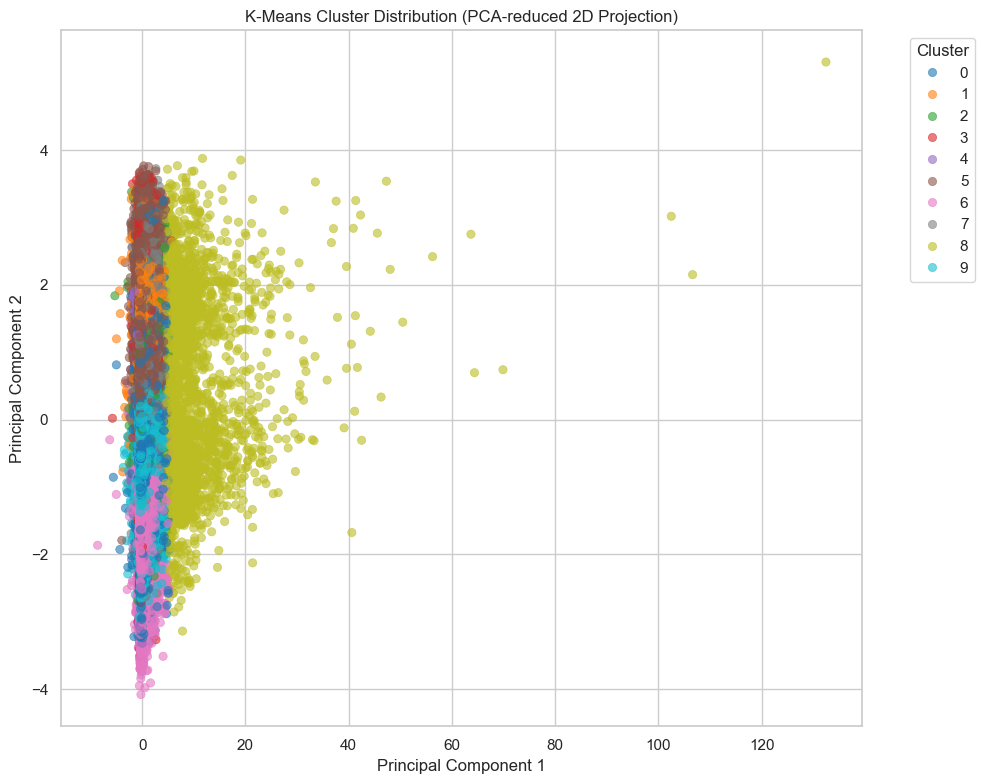

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize PCA and reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_to_predict)

# 2. Add PCA components to the processed_df for plotting
processed_df['PCA1'] = X_pca[:, 0]
processed_df['PCA2'] = X_pca[:, 1]

# 3. Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=processed_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    alpha=0.6,
    edgecolor=None
)

# 4. Add titles and labels
plt.title('K-Means Cluster Distribution (PCA-reduced 2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Show the plot
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# --- 1. Setup and Data Loading ---

FILE_PATH = 'creditcard.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{FILE_PATH}' was not found. Please check the file path.")
    exit()

# --- 2. Data Cleaning and Splitting ---

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Identify and remove rows with any NaN values in X or y
nan_indices = y[y.isna()].index.tolist() + X[X.isna().any(axis=1)].index.tolist()
nan_indices = list(set(nan_indices))

if nan_indices:
    X_clean = X.drop(nan_indices)
    y_clean = y.drop(nan_indices)
    print(f"Removed {len(nan_indices)} rows containing NaN values.")
else:
    X_clean = X
    y_clean = y
    print("No NaN values found. Proceeding with original data.")

# Split the cleaned data into training (80%) and testing (20%) sets
# Stratify ensures fraud cases are balanced across sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# --- 3. Feature Scaling ---

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split and scaled. Training set shape: {X_train_scaled.shape}")
print("-" * 60)


# --- 4. K-MEANS ANOMALY DETECTION (For Comparison) ---

K_CLUSTERS = 10
random_state = 42

print("Running K-Means Anomaly Detection...")

# Train K-Means
kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=random_state, n_init=10)
kmeans.fit(X_train_scaled)

# Calculate Anomaly Scores (min distance to any centroid) for the test set
distances_to_centers = kmeans.transform(X_test_scaled)
anomaly_scores_kmeans = np.min(distances_to_centers, axis=1)

# Determine the threshold (e.g., 90th percentile of non-fraud scores)
non_fraud_indices = y_test[y_test == 0].index
non_fraud_scores = anomaly_scores_kmeans[np.isin(np.arange(len(y_test)), non_fraud_indices)]
THRESHOLD = np.percentile(non_fraud_scores, 90)

# Convert scores to binary predictions
y_pred_kmeans = (anomaly_scores_kmeans > THRESHOLD).astype(int)

# Evaluate K-Means
precision_kmeans = precision_score(y_test, y_pred_kmeans)
recall_kmeans = recall_score(y_test, y_pred_kmeans)
f1_kmeans = f1_score(y_test, y_pred_kmeans)
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

print(f"K-Means Evaluation (Threshold={THRESHOLD:.4f}):")
print(f"  Precision: {precision_kmeans:.4f}, Recall: {recall_kmeans:.4f}, F1-Score: {f1_kmeans:.4f}")
print("  Confusion Matrix:\n", cm_kmeans)
print("-" * 60)


# --- 5. ISOLATION FOREST (Specialized Anomaly Detection) ---

print("Running Isolation Forest Anomaly Detection...")

# Calculate the fraud rate for contamination parameter
fraud_rate = len(y_train[y_train == 1]) / len(y_train)

# Initialize and Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=fraud_rate,
    random_state=random_state,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)

# Predict Anomalies
y_pred_iso_raw = iso_forest.predict(X_test_scaled)

# Map predictions: -1 (anomaly) -> 1 (Fraud), 1 (normal) -> 0 (Not Fraud)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)

# Evaluate Isolation Forest
precision_iso = precision_score(y_test, y_pred_iso)
recall_iso = recall_score(y_test, y_pred_iso)
f1_iso = f1_score(y_test, y_pred_iso)
cm_iso = confusion_matrix(y_test, y_pred_iso)

print(f"Isolation Forest Evaluation (Contamination={fraud_rate:.4f}):")
print(f"  Precision: {precision_iso:.4f}, Recall: {recall_iso:.4f}, F1-Score: {f1_iso:.4f}")
print("  Confusion Matrix:\n", cm_iso)
print("-" * 60)


# --- 6. Visualization of Clusters (t-SNE) ---

print("Generating 2D t-SNE visualization...")

# Use a smaller subset for faster calculation
X_test_subset = X_test_scaled[:20000]
y_test_subset = y_test[:20000]

# Dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_test_2d = tsne.fit_transform(X_test_subset)

# Predict cluster labels for the t-SNE subset
cluster_labels_2d = kmeans.predict(X_test_subset)

# Create DataFrame for plotting
plot_df = pd.DataFrame(data=X_test_2d, columns=['tsne_1', 'tsne_2'])
plot_df['Cluster'] = cluster_labels_2d
plot_df['Actual_Fraud'] = y_test_subset.values

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='Cluster', data=plot_df, palette='tab10', alpha=0.6, s=20)
plt.title('K-Means Clusters in 2D (t-SNE)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='Actual_Fraud', data=plot_df, palette={0: 'blue', 1: 'red'}, alpha=0.7, s=20)
plt.title('Actual Fraudulent Transactions')

plt.tight_layout()
plt.show()
print("Visualization complete.")
print("-" * 60)


# --- 7. Create the Fraud-Only Dataset ---

# Filter the cleaned original data where 'Class' is 1
actual_fraud_transactions = X_clean[y_clean == 1].copy()
actual_fraud_transactions['Class'] = 1 # Re-add the class label for clarity

print("DataFrame Containing ONLY Actual Fraudulent Transactions:")
print(f"Total number of fraudulent transactions: {len(actual_fraud_transactions)}")
print(actual_fraud_transactions.head())

## Model Training 

In [6]:
def train_fraud_model(file_path):
    import pandas as pd
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    # 1. Load the CSV
    df_internal = pd.read_csv(file_path)

    # 2. Preprocessing
    # Handle missing values if any
    if df_internal.isnull().sum().sum() > 0:
        df_internal = df_internal.dropna()

    # Separate features (drop 'Class') and keep labels for later density analysis
    X_internal = df_internal.drop(columns=['Class'])

    # Scale the features using a new instance of StandardScaler
    scaler_internal = StandardScaler()
    X_scaled_internal = scaler_internal.fit_transform(X_internal)

    # 3. Instantiate KMeans
    # Using 10 clusters as a reasonable starting point for identifying fraud patterns
    kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')

    # 4. Fit the model
    kmeans.fit(X_scaled_internal)

    # 5. Return the fitted model, scaler, and the processed DataFrame
    return kmeans, scaler_internal, df_internal

# 6. Call the function
kmeans_model, fitted_scaler, processed_df = train_fraud_model('creditcard.csv')

print("Model training complete.")
print(f"Number of clusters: {kmeans_model.n_clusters}")
print(f"Processed DataFrame shape: {processed_df.shape}")

Model training complete.
Number of clusters: 10
Processed DataFrame shape: (284807, 31)


## Fraud Detection 

In [7]:
import numpy as np

# 1. Predict cluster assignments and add to processed_df
# We use the scaled features from the training process; if they aren't in scope, we re-scale
X_to_predict = fitted_scaler.transform(processed_df.drop(columns=['Class']))
processed_df['Cluster'] = kmeans_model.predict(X_to_predict)

# 2. Calculate fraud density (mean of 'Class') for each cluster
cluster_fraud_density = processed_df.groupby('Cluster')['Class'].mean()

# 3. Identify the cluster index with the highest fraud density
fraud_cluster_index = cluster_fraud_density.idxmax()
max_density = cluster_fraud_density.max()

# 4. Create a mapping/logic for classification
def classify_cluster(cluster_id):
    return "Fraud" if cluster_id == fraud_cluster_index else "Not Fraud"

# 5. Print fraud density per cluster and the identified fraud cluster
print("Fraud Density per Cluster:")
print(cluster_fraud_density)
print(f"\nIdentified Fraud Cluster Index: {fraud_cluster_index} (Density: {max_density:.4f})")

Fraud Density per Cluster:
Cluster
0    0.000384
1    0.000288
2    0.000212
3    0.045816
4    0.006865
5    0.000353
6    0.000986
7    0.000058
8    0.002549
9    0.000796
Name: Class, dtype: float64

Identified Fraud Cluster Index: 3 (Density: 0.0458)


## Model Evaluation

In [8]:
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report

# 1. Calculate Silhouette Score on a sample (10,000) for efficiency
sample_size = 10000
if len(X_to_predict) > sample_size:
    idx = np.random.choice(len(X_to_predict), sample_size, replace=False)
    X_sample = X_to_predict[idx]
    labels_sample = processed_df['Cluster'].iloc[idx]
else:
    X_sample = X_to_predict
    labels_sample = processed_df['Cluster']

sil_score = silhouette_score(X_sample, labels_sample)
print(f"Silhouette Score (Sample of {sample_size}): {sil_score:.4f}")

# 2. Map clusters to binary predictions (1 for Fraud, 0 for Not Fraud)
# Using the previously identified fraud_cluster_index
processed_df['Pred_Class'] = processed_df['Cluster'].apply(lambda x: 1 if x == fraud_cluster_index else 0)

# 3. Generate Confusion Matrix
conf_matrix = confusion_matrix(processed_df['Class'], processed_df['Pred_Class'])

# 4. Print results and detailed classification report
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(processed_df['Class'], processed_df['Pred_Class'], target_names=['Not Fraud', 'Fraud']))

Silhouette Score (Sample of 10000): 0.0673

Confusion Matrix:
[[277484   6831]
 [   164    328]]

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    284315
       Fraud       0.05      0.67      0.09       492

    accuracy                           0.98    284807
   macro avg       0.52      0.82      0.54    284807
weighted avg       1.00      0.98      0.99    284807



## Gradio UI 

# logic

In [9]:
import io
import pandas as pd
import numpy as np

def predict_single_transaction(csv_string):
    try:
        # Split and convert string to numeric array
        features = [float(x.strip()) for x in csv_string.split(',')]
        if len(features) != 30:
            return f"Error: Expected 30 features, got {len(features)}"

        # Create DataFrame to maintain feature names and avoid sklearn warnings
        feature_names = fitted_scaler.feature_names_in_
        input_df = pd.DataFrame([features], columns=feature_names)

        # Use existing global fitted_scaler and kmeans_model
        input_scaled = fitted_scaler.transform(input_df)
        cluster_id = kmeans_model.predict(input_scaled)[0]

        # Use existing global fraud_cluster_index
        return "Fraud" if cluster_id == fraud_cluster_index else "Not Fraud"
    except Exception as e:
        return f"Error processing input: {str(e)}"

def predict_batch_csv(file_obj):
    try:
        # Load CSV
        batch_df = pd.read_csv(file_obj)

        # Ensure we only have the 30 expected features (drop 'Class' if present)
        if 'Class' in batch_df.columns:
            features_df = batch_df.drop(columns=['Class'])
        else:
            features_df = batch_df

        if features_df.shape[1] != 30:
            return f"Error: Expected 30 feature columns, found {features_df.shape[1]}"

        # Align feature names with the fitted scaler
        features_df.columns = fitted_scaler.feature_names_in_

        # Scale and predict
        scaled_data = fitted_scaler.transform(features_df)
        clusters = kmeans_model.predict(scaled_data)

        # Map to Fraud/Not Fraud
        batch_df['Prediction'] = ["Fraud" if c == fraud_cluster_index else "Not Fraud" for c in clusters]
        return batch_df
    except Exception as e:
        return f"Error processing file: {str(e)}"

# --- Testing Logic ---
print("--- Testing Single Prediction ---")
sample_row = processed_df.drop(columns=['Class', 'Cluster', 'Pred_Class']).iloc[0]
sample_string = ",".join(map(str, sample_row.values))
print(f"Input String (First 50 chars): {sample_string[:50]}...")
print(f"Result: {predict_single_transaction(sample_string)}")

print("\n--- Testing Batch Prediction ---")
test_sample = processed_df.drop(columns=['Cluster', 'Pred_Class']).sample(5)
csv_buffer = io.StringIO()
test_sample.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)
batch_results = predict_batch_csv(csv_buffer)
print(batch_results[['Class', 'Prediction']])

--- Testing Single Prediction ---
Input String (First 50 chars): 0.0,-1.3598071336738,-0.0727811733098497,2.5363467...
Result: Not Fraud

--- Testing Batch Prediction ---
   Class Prediction
0      0  Not Fraud
1      0  Not Fraud
2      0  Not Fraud
3      0  Not Fraud
4      0  Not Fraud


## Extract Sample Data

In [10]:
def get_random_transaction_string(df):
    # 1. Select exactly one random row
    sample = df.sample(n=1, random_state=None)

    # 2. Identify the 30 feature columns (exclude target/metadata columns)
    feature_cols = [col for col in df.columns if col not in ['Class', 'Cluster', 'Pred_Class']]

    # 3. Extract numeric values for that row
    values = sample[feature_cols].values[0]

    # 4. Join values into a single comma-separated string
    transaction_string = ','.join(map(str, values))

    return transaction_string

# Test the function with the existing processed_df
random_sample_string = get_random_transaction_string(processed_df)
print("Generated Random Transaction String:")
print(random_sample_string)
print(f"\nNumber of features in string: {len(random_sample_string.split(','))}")

Generated Random Transaction String:
38163.0,1.46212566101624,-0.304158976183614,-0.405742621191944,-0.767114260113676,-0.367506709507571,-1.10858136163141,0.0065083110060199,-0.406990558163812,-1.18409172200575,0.669538366207962,-0.601271603080312,-0.553676195636883,0.633565875621479,0.0029868786711787,0.413411788514005,0.853099187362495,0.20298763706638,-1.4890969108009,0.816384600544235,0.13111926793619,0.169424817849541,0.422118770633987,-0.241261637939152,-0.0597793260571698,0.869542374944958,-0.0564895369707519,-0.0288189661310792,-0.0002677881350217,25.0

Number of features in string: 30


## Data Visualization

## Update Gradio Interface

In [14]:
def populate_random_transaction():
    # Use the existing get_random_transaction_string with the global processed_df
    return get_random_transaction_string(processed_df)

with gr.Blocks(title="Enhanced Credit Card Fraud Detector") as demo:
    gr.Markdown("# Credit Card Fraud Detection System")
    gr.Markdown("Use the 'Generate Random Transaction' button to quickly test the model with real data from the dataset.")

    with gr.Tabs():
        with gr.Tab("Single Transaction"):
            gr.Markdown("### Predict Single Transaction")
            gr.Markdown("Enter 30 comma-separated feature values or generate a random sample.")

            single_input = gr.Textbox(label="Comma-separated Features", placeholder="0.0, -1.35, ...")

            with gr.Row():
                random_btn = gr.Button("Generate Random Transaction", variant="secondary")
                single_btn = gr.Button("Classify Transaction", variant="primary")

            single_output = gr.Textbox(label="Prediction Result")

            # Event for generating random data
            random_btn.click(fn=populate_random_transaction, inputs=None, outputs=single_input)

            # Event for classification
            single_btn.click(fn=predict_single_transaction, inputs=single_input, outputs=single_output)

        with gr.Tab("Batch Prediction"):
            gr.Markdown("### Predict Batch via CSV")
            batch_input = gr.File(label="Upload CSV File", file_types=[".csv"])
            batch_output = gr.Dataframe(label="Prediction Results")
            batch_btn = gr.Button("Run Batch Prediction")
            batch_btn.click(fn=predict_batch_csv, inputs=batch_input, outputs=batch_output)

# Launch the updated interface
demo.launch(share=True)
print("Gradio interface launched with Random Generator.")

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Gradio interface launched with Random Generator.
